Using device: cuda
[tensor([0, 0, 0, 1, 1, 1]), tensor([1, 1, 1, 0, 0, 0]), tensor([1, 0, 1, 0, 1, 0]), tensor([0, 1, 0, 1, 0, 1]), tensor([0, 1, 1, 0, 1, 0]), tensor([1, 0, 0, 1, 0, 1]), tensor([0, 0, 1, 0, 1, 1]), tensor([1, 1, 0, 1, 0, 0]), tensor([0, 0, 0, 1, 1, 1]), tensor([1, 1, 1, 0, 0, 0]), tensor([1, 0, 1, 0, 1, 0]), tensor([0, 1, 0, 1, 0, 1]), tensor([1, 1, 0, 0, 1, 0]), tensor([0, 0, 1, 1, 0, 1]), tensor([0, 0, 1, 0, 1, 1]), tensor([1, 1, 0, 1, 0, 0]), tensor([1, 1, 0, 1, 0, 0]), tensor([0, 0, 1, 0, 1, 1]), tensor([1, 1, 0, 0, 1, 0]), tensor([0, 0, 1, 1, 0, 1])]
Epoch 50, Loss: 5.648038387298584
Epoch 100, Loss: 5.599756240844727
final best loss: 5.535073280334473


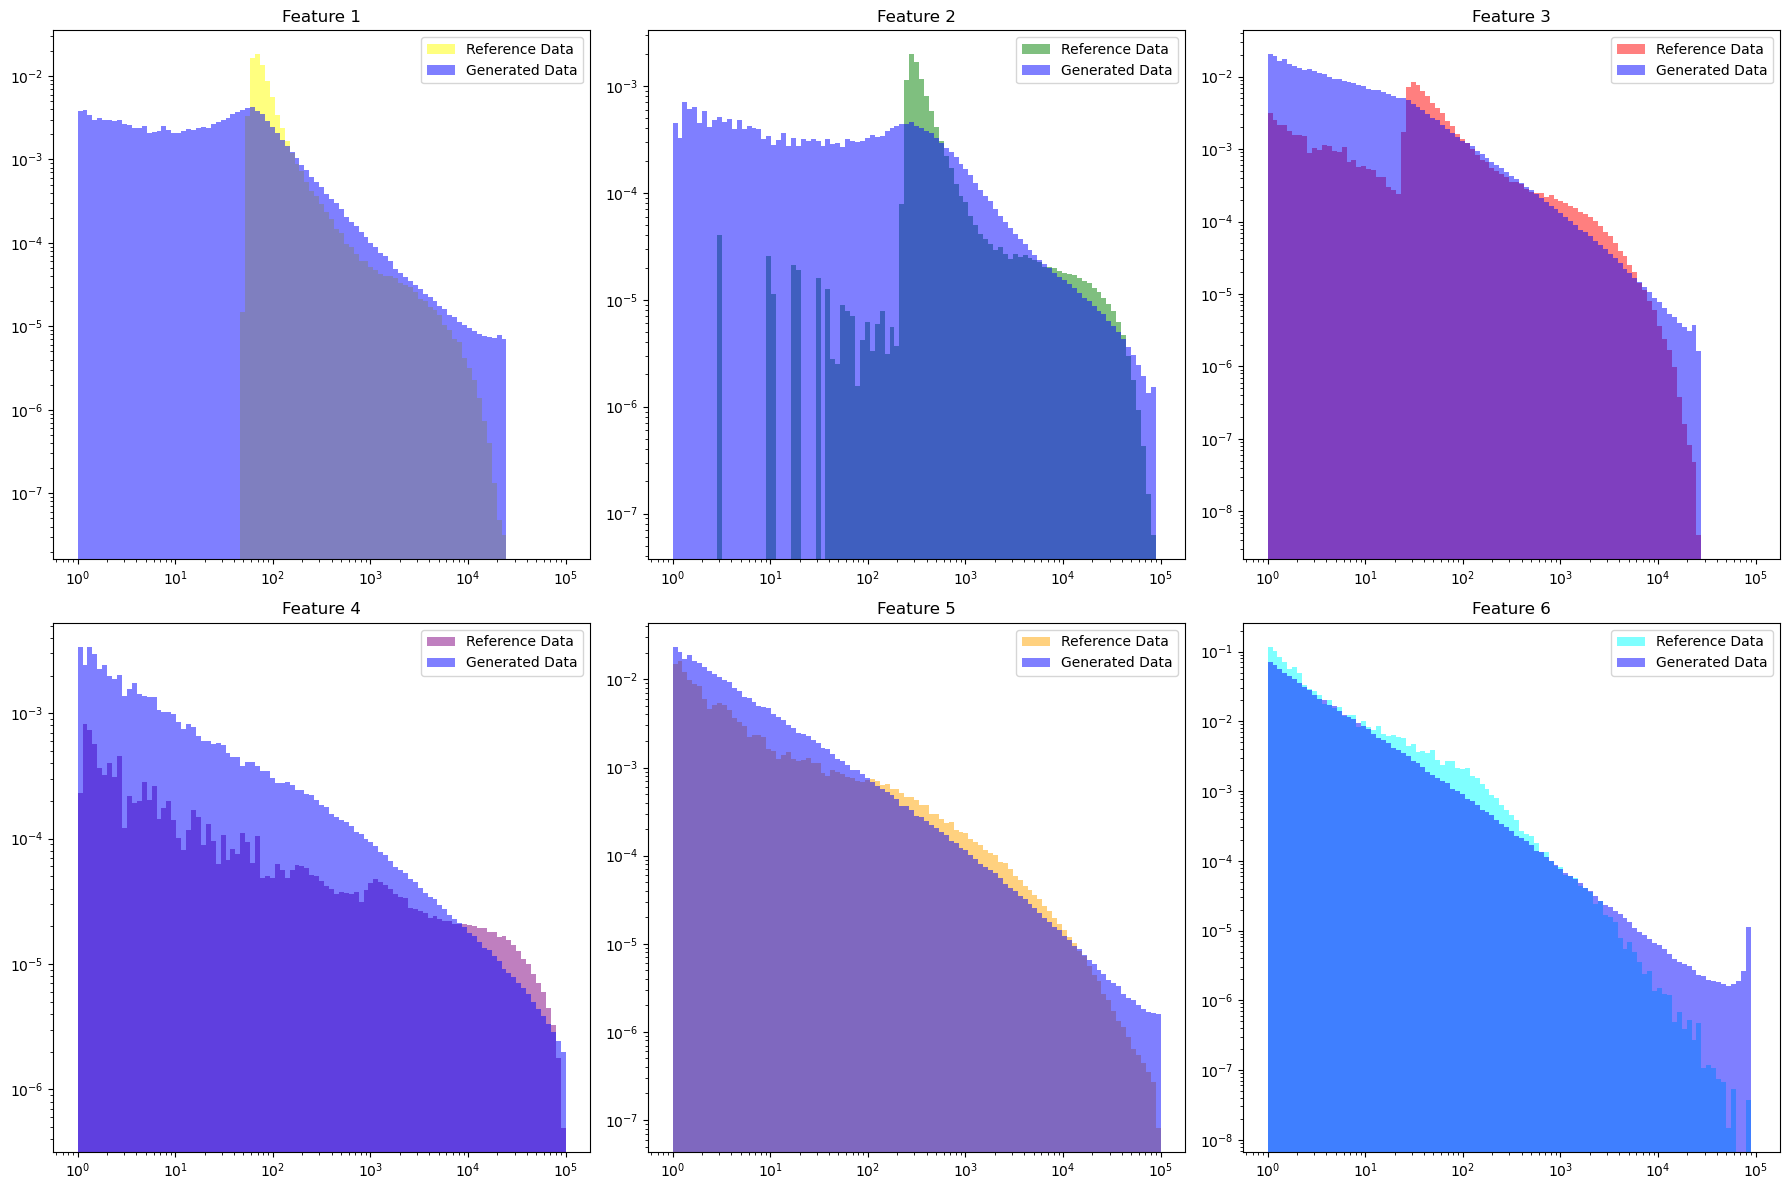

In [1]:
import numpy as np  
import h5py
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
from nflows.flows.base import Flow
from nflows.distributions.normal import StandardNormal
from nflows.transforms.base import CompositeTransform
from nflows.transforms.coupling import PiecewiseRationalQuadraticCouplingTransform 
from nflows.transforms.permutations import ReversePermutation
from nflows.transforms.coupling import AffineCouplingTransform
import time
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

ALPHA = 1e-6

def logit(x):
    return torch.log(x / (1.0 - x))

def logit_trafo(x):
    local_x = torch.clamp(ALPHA + (1. - 2. * ALPHA) * x, min=1e-6, max=1 - 1e-6)
    return logit(local_x)

def inverse_logit(x):
    return (torch.sigmoid(x) - ALPHA) / (1. - 2.*ALPHA)

# Load and preprocess data
path_to_data = '/groups/hephy/mlearning/CaloRegression/training/'
my_file = h5py.File(path_to_data + 'train_piplus.hdf5', 'r')
energy = my_file['energy'][:]
layers = [my_file[f'layer_{i}'][:] for i in range(6)]
E_layers = np.array([layer.sum(axis=(1, 2)) for layer in layers]).T

data = np.hstack((energy.reshape(-1, 1), E_layers))
data[np.isinf(data)] = np.nan
valid_mask = ~np.isnan(data).any(axis=1)
data = data[valid_mask]

data_tensor = torch.tensor(data, dtype=torch.float32).to(device)

data_max = data_tensor.max(dim=0).values
data_tensor = data_tensor / data_max
data_tensor = logit_trafo(data_tensor)

mask = ~torch.isnan(data_tensor).any(dim=1) & ~torch.isinf(data_tensor).any(dim=1)
data_tensor = data_tensor[mask]

data_mean = data_tensor.mean(dim=0)
data_std = data_tensor.std(dim=0)
data_tensor = (data_tensor - data_mean) / data_std

data_mean_reg = data_mean
data_std_reg = data_std
data_max_reg = data_max


context_feature = data_tensor[:, 0].unsqueeze(1)
input_features = data_tensor[:, 1:]

# Define the Flow model
num_layers = 20  
num_features = input_features.shape[1]
base_distribution = StandardNormal(shape=[num_features])

transforms = []

# Create alternating masks for coupling layers
#old version:
#masks = [torch.arange(num_features) % 2 for _ in range(num_layers)]
#masks = [mask if i%2==0 else 1-mask for i,mask in enumerate(masks)]

masks = [(torch.arange(num_features) % 2).bool() for _ in range(num_layers)]
masks = [mask if i % 2 == 0 else ~mask for i, mask in enumerate(masks)]

masks = []
for i in range(num_layers):
    if i % 2 == 0:
        masks.append(torch.tensor(np.random.choice([0,0,0,1,1,1], replace=False,size=6)))
    else:
        masks.append(1-masks[-1])

print(masks)

# Define a custom MLP for the transformation network
class CouplingMLP(nn.Module):
    def __init__(self, in_features, out_features, context_features=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features + context_features, 128), nn.LeakyReLU(0.01),
            nn.Linear(128, 128), nn.LeakyReLU(0.01),
            nn.Linear(128, out_features)
        )

    def forward(self, identity_split, context):
        inputs = torch.cat([identity_split, context], dim=-1)
        return self.net(inputs)


# Modify Flow model to use the custom MLP
for i in range(num_layers):
   # transforms.append(ReversePermutation(features=num_features))
    transforms.append(AffineCouplingTransform(
        mask=masks[i],
        transform_net_create_fn=lambda in_features, out_features: CouplingMLP(in_features, out_features, context_features=1)
    ))

transform = CompositeTransform(transforms)
flow = Flow(transform, base_distribution).to(device)

def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

flow.apply(init_weights)


# Training the Flow
#changed: old version
#optimizer = torch.optim.Adam(flow.parameters(), lr=1e-4)
optimizer = torch.optim.Adam(flow.parameters(), lr=1e-3)
num_epochs = 100
batch_size = 256
best_loss = float('inf')

for epoch in range(num_epochs):
    idx = torch.randperm(len(data_tensor))
    data_tensor = data_tensor[idx]
    context_feature = data_tensor[:, 0].unsqueeze(1)
    input_features = data_tensor[:, 1:]

    for i in range(0, len(input_features), batch_size):
        batch_inputs = input_features[i:i + batch_size]
        batch_context = context_feature[i:i + batch_size]
        optimizer.zero_grad()
        loss = -flow.log_prob(inputs=batch_inputs, context=batch_context).mean()
        if not torch.isnan(loss) and not torch.isinf(loss):
            loss.backward()
            optimizer.step()
            best_loss = min(best_loss, loss.item())
        else:
            print("skipping")
        #print(f"batch {i}, Loss: {loss.item()}")
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss.item()}")
        
print(f"final best loss: {best_loss}")
# Generate Samples
n_samples = 200000
batch_size = 1000
all_samples = []

Einc_gen = torch.rand((n_samples, 1)).to(device) * 99 + 1
Einc_gen = Einc_gen / data_max[0]
Einc_gen = logit_trafo(Einc_gen)
Einc_gen = (Einc_gen - data_mean[0]) / data_std[0]

with torch.no_grad():
    for i in range(0, n_samples, batch_size):
        batch_context = Einc_gen[i:i + batch_size]
        samples_batch = flow.sample(1, context=batch_context).detach().cpu()
        all_samples.append(samples_batch)

samples = torch.cat(all_samples, dim=0)
samples = samples * data_std[1:].cpu() + data_mean[1:].cpu()
samples = inverse_logit(samples)
samples = samples * data_max[1:].cpu()
samples = samples.squeeze().numpy()

# Plot Histograms
fig, axs = plt.subplots(2, 3, figsize=(18, 12))  # Adjust width and heigh

axs = axs.flatten()
colors = ['yellow', 'green', 'red', 'purple', 'orange', 'cyan']

for i in range(data.shape[1] - 1):
    bins = np.logspace(0, 5, 100)
    counts, bin_edges, _ = axs[i].hist(
        data[:, i + 1], bins=bins, alpha=0.5, label="Reference Data", color=colors[i % len(colors)], density=True, log=True
    )
    axs[i].hist(samples[:, i], bins=bin_edges, alpha=0.5, label="Generated Data", color='blue', density=True, log=True)
    axs[i].set_xscale('log')
    axs[i].legend()
    axs[i].set_title(f"Feature {i + 1}")

for j in range(len(axs)):
    if j >= data.shape[1] - 1:
        axs[j].axis('off')

plt.tight_layout()

plt.show()

In [2]:
#CLASSIFIER
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import copy

ALPHA = 1e-6

import numpy as np

def logit(x):
    return np.log(x / (1.0 - x))

def logit_trafo(x):
    local_x = np.clip(ALPHA + (1. - 2. * ALPHA) * x, 1e-6, 1 - 1e-6)
    return logit(local_x)


real_data = data_tensor.cpu().numpy()
Einc_gen_numpy = Einc_gen.cpu().numpy().reshape(-1, 1) 
samples_with_einc = np.hstack((Einc_gen_numpy, samples))  
generated_data = samples_with_einc

print(type(real_data))
print(type(generated_data))

# Compute max, mean, std based on **combined** dataset
combined = np.vstack((real_data, generated_data))

data_max = combined.max(axis=0)
data_mean = combined.mean(axis=0)
data_std = combined.std(axis=0)

# Apply same transformations to both datasets
real_data = real_data / data_max
generated_data = generated_data / data_max

real_data = logit_trafo(real_data)
generated_data = logit_trafo(generated_data)

real_data = (real_data - data_mean) / data_std
generated_data = (generated_data - data_mean) / data_std

#added here because auc was wrong
# Drop the first column (Einc) before using for classification
real_data = real_data[:, 1:]
generated_data = generated_data[:, 1:]

#changes end here

# Create labels
smallest_size = min(len(real_data), len(generated_data))

# Randomly select smallest_size indices
real_indices = np.random.choice(len(real_data), smallest_size, replace=False)
generated_indices = np.random.choice(len(generated_data), smallest_size, replace=False)

# Select only those samples
real_data = real_data[real_indices]
generated_data = generated_data[generated_indices]

print(f"Final real data shape: {real_data.shape}")
print(f"Final gen shape: {generated_data.shape}")

real_labels = np.ones(len(real_data))  
maf_labels = np.zeros(len(generated_data))

# combining of real and KDE gen data
#combined_data = np.vstack((real_data[:, 1:], generated_data))
combined_data = np.vstack((real_data, generated_data))
combined_labels = np.hstack((real_labels, maf_labels))

# split into trainning and test sets
X_train, X_test, y_train, y_test = train_test_split(combined_data, combined_labels, test_size=0.2, random_state=42)

#CLASSIFIER SETUP
class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        x = F.leaky_relu(self.fc1(x), negative_slope=0.01)
        x = self.dropout(x)
        x = F.leaky_relu(self.fc2(x), negative_slope=0.01)
        x = self.dropout(x)
        x = torch.sigmoid(self.fc3(x))
        return x

def train_model(model, criterion, optimizer, dataloaders, num_epochs=25):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        print('Epoch number {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device).float().unsqueeze(1)
                
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    preds = torch.round(outputs)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print('{} Loss: {:.9f} Acc: {:.9f}'.format(
                phase, epoch_loss, epoch_acc))

            if phase == 'val' and epoch_acc  > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

    print('highest validation accuracy: {:9f}'.format(best_acc))
    model.load_state_dict(best_model_wts)
    return model

def evaluate_model(model, dataloaders):
    model.eval()
    all_preds = []
    all_labels = []
    all_preds_auc = []

    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        labels = labels.to(device).float().unsqueeze(1)
        
        with torch.no_grad():
            outputs = model(inputs)
            preds = torch.round(outputs)
            preds_auc = outputs
            all_preds_auc.append(preds_auc.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    
    all_preds_auc = np.concatenate(all_preds_auc)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_preds_auc)
    print('Accuracy: {:.9f}, AUC (area under roc curve): {:.9f}'.format(acc, auc))
    return acc, auc

# dataloader setup
train_dataset = torch.utils.data.TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
test_dataset = torch.utils.data.TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))

dataloaders = {
    'train': torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=True)
}

# Model, criterion, optimizer
input_dim = combined_data.shape[1]
hidden_dim = 64
model = SimpleNN(input_dim, hidden_dim)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# train & evaluate
model = train_model(model, criterion, optimizer, dataloaders, num_epochs=25)
evaluate_model(model, dataloaders)


#end_time = time.time()

#elapsed_time = end_time - start_time
#hours, rem = divmod(elapsed_time, 3600)
#minutes, seconds = divmod(rem, 60)
#print(f"Total time taken: {int(hours)}h {int(minutes)}m {seconds:.2f}s")

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
Final real data shape: (70000, 6)
Final gen shape: (70000, 6)
Epoch number 0/24
----------
train Loss: 0.693347322 Acc: 0.501410714
val Loss: 0.693185410 Acc: 0.496607143
Epoch number 1/24
----------
train Loss: 0.693175596 Acc: 0.502133929
val Loss: 0.693466702 Acc: 0.496607143
Epoch number 2/24
----------
train Loss: 0.693197748 Acc: 0.501330357
val Loss: 0.693343250 Acc: 0.496607143
Epoch number 3/24
----------
train Loss: 0.693192561 Acc: 0.501089286
val Loss: 0.693162968 Acc: 0.496607143
Epoch number 4/24
----------
train Loss: 0.693188743 Acc: 0.500687500
val Loss: 0.693127869 Acc: 0.503392857
Epoch number 5/24
----------
train Loss: 0.693189521 Acc: 0.504044643
val Loss: 0.693335402 Acc: 0.496607143
Epoch number 6/24
----------
train Loss: 0.693181750 Acc: 0.501973214
val Loss: 0.693090107 Acc: 0.503392857
Epoch number 7/24
----------
train Loss: 0.693193290 Acc: 0.500250000
val Loss: 0.693155589 Acc: 0.496607143
Epoch number 8/24


(0.5033928571428572, 0.9829443217984909)

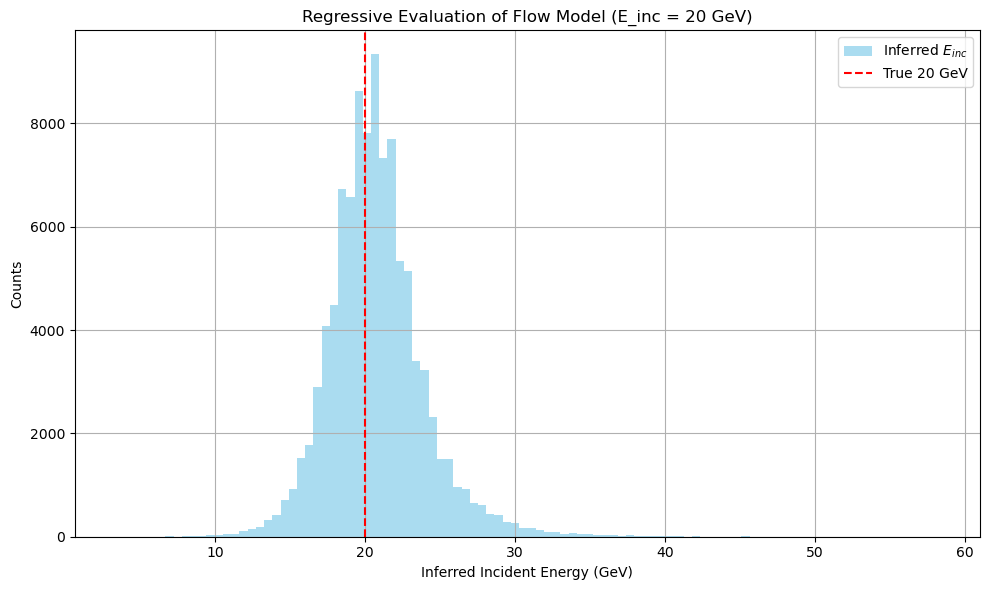

In [3]:
test_file_path = '/groups/hephy/mlearning/CaloRegression/evaluation/piplus_20GeV.hdf5'


def logit_reg(x):
    return torch.log(x / (1.0 - x))

def logit_trafo_reg(x):
    local_x = torch.clamp(ALPHA + (1. - 2. * ALPHA) * x, min=1e-6, max=1 - 1e-6)
    return logit_reg(local_x)

def inverse_logit_reg(x):
    return (torch.sigmoid(x) - ALPHA) / (1. - 2.*ALPHA)

#LOAD AND PREPROCESS TEST DATA
def load_and_preprocess_test_file(filepath, data_mean_reg, data_std_reg, data_max_reg):
    with h5py.File(filepath, 'r') as f:
        energy = f['energy'][:]
        layers = [f[f'layer_{i}'][:] for i in range(6)]
        E_layers = np.array([layer.sum(axis=(1, 2)) for layer in layers]).T

    data = np.hstack((energy.reshape(-1, 1), E_layers))
    data[np.isinf(data)] = np.nan
    valid_mask = ~np.isnan(data).any(axis=1)
    data = data[valid_mask]

    tensor_data = torch.tensor(data, dtype=torch.float32).to(device)
    #preprocessing
    tensor_data = tensor_data / data_max_reg  
    tensor_data = logit_trafo_reg(tensor_data)  
    tensor_data = (tensor_data - data_mean_reg) / data_std_reg 

    return tensor_data[:, 1:]  #return only layers (context is inferred)

#ENERGY INFERENCE
def infer_incident_energy(flow, layer_tensor, data_mean_reg, data_std_reg, data_max_reg, num_scan_points=1000):
    device = layer_tensor.device
    n_samples = layer_tensor.shape[0]
    E_candidates = torch.linspace(1, 100, num_scan_points, device=device).view(-1, 1)

    E_candidates_norm = E_candidates / data_max_reg[0]
    E_candidates_logit = logit_trafo_reg(E_candidates_norm)
    E_candidates_std = (E_candidates_logit - data_mean_reg[0]) / data_std_reg[0]

    #prep context
    E_context = E_candidates_std.view(1, -1, 1).repeat(n_samples, 1, 1)  # [n_samples, num_scan_points, 1]
    inputs = layer_tensor.unsqueeze(1).repeat(1, num_scan_points, 1)     # [n_samples, num_scan_points, features]


    flat_inputs = inputs.view(-1, inputs.shape[-1])      # [n_samples *num_scan_points, features]
    flat_context = E_context.view(-1, 1)                 # [n_samples *num_scan_points, 1]

    batch_size = 1000  
    log_probs_list = []
    with torch.no_grad():
        for i in range(0, flat_inputs.shape[0], batch_size):
            inputs_batch = flat_inputs[i:i + batch_size]
            context_batch = flat_context[i:i + batch_size]
            log_probs_batch = flow.log_prob(inputs_batch, context=context_batch)
            log_probs_list.append(log_probs_batch)

    log_probs = torch.cat(log_probs_list).view(n_samples, num_scan_points)
   
    #select max logprob index for each sample 
    max_indices = log_probs.argmax(dim=1)
    inferred_E = E_candidates[max_indices].cpu().numpy()

    #return log_probs
    return inferred_E

#training values
data_mean_reg = data_mean_reg.to(device)
data_std_reg = data_std_reg.to(device)    
data_max_reg = data_max_reg.to(device)   
flow =flow.to(device)   

test_layers_tensor = load_and_preprocess_test_file(test_file_path, data_mean_reg, data_std_reg, data_max_reg)
inferred_energies = infer_incident_energy(flow, test_layers_tensor, data_mean_reg, data_std_reg, data_max_reg)
#print(inferred_energies)

plt.figure(figsize=(10, 6))
plt.hist(inferred_energies, bins=100, alpha=0.7, color='skyblue', label="Inferred $E_{inc}$")
plt.axvline(20, color='red', linestyle='--', label='True 20 GeV')
plt.xlabel("Inferred Incident Energy (GeV)")
plt.ylabel("Counts")
plt.legend()
plt.title("Regressive Evaluation of Flow Model (E_inc = 20 GeV)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
#for element in inferred_energies:
 #   element = element.cpu().numpy()
  #  print(element.shape)
   # E_candidates = np.linspace(1, 100, 100)
    #plt.plot(E_candidates, element)
    #plt.show()

In [4]:
inferred_energies[0]

array([21.513514], dtype=float32)

=== Test Input Diagnostics ===
test_layers_tensor[:5]: tensor([[ -5.8704,  -5.8208,  -6.8126,  -2.0483,  -3.2249, -13.8155],
        [ -5.5347,  -5.0265,  -6.5492,  -2.7033,  -2.7727,  -9.8764],
        [ -6.0330,  -5.3934,  -5.9181,  -1.5567, -12.3420, -13.8155],
        [ -6.0059,  -5.7271,  -2.6173,  -2.0687,  -5.4557, -13.8155],
        [ -2.8527,  -1.8500,  -3.9339,  -3.8338, -13.8155, -13.8155]])
test_layers_tensor.std(): 4.007924556732178

=== Debug Info ===
data_max[0]: 7.950750350952148
data_mean[0]: -0.00034994466113857925
data_std[0]: 1.002991795539856
E_candidates[:5]: [1.        1.0990992 1.1981982 1.2972972 1.3963964]
E_candidates_norm[:5]: [1.25774294e-01 4.24832397e-05 1.12347252e-05 3.96195246e-05
 8.22517541e-06 8.96851907e-06 1.15660532e-05 1.38238415e-01
 4.66932906e-05 1.23480768e-05 4.35457878e-05 9.04028275e-06
 9.85729184e-06 1.27122394e-05 1.50702536e-01 5.09033380e-05
 1.34614274e-05 4.74720437e-05 9.85539009e-06 1.07460637e-05
 1.38584246e-05 1.63166642e-01 5

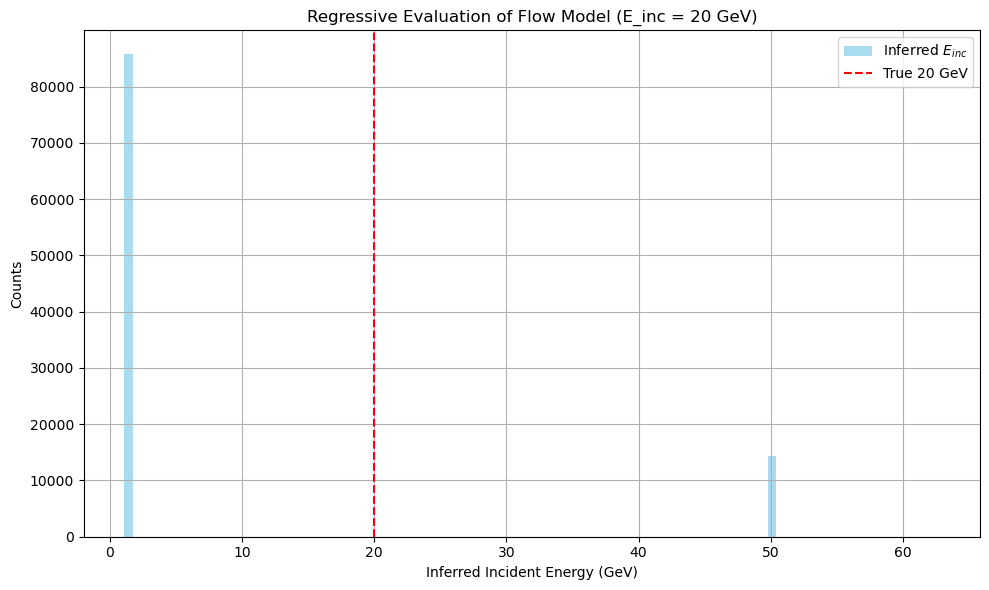

In [5]:
test_file_path = '/groups/hephy/mlearning/CaloRegression/evaluation/piplus_20GeV.hdf5'


def logit_reg(x):
    return torch.log(x / (1.0 - x))

def logit_trafo_reg(x):
    local_x = torch.clamp(ALPHA + (1. - 2. * ALPHA) * x, min=1e-6, max=1 - 1e-6)
    return logit_reg(local_x)

def inverse_logit_reg(x):
    return (torch.sigmoid(x) - ALPHA) / (1. - 2.*ALPHA)

# LOAD AND PREPROCESS TEST DATA ===
def load_and_preprocess_test_file(filepath, data_mean, data_std, data_max):
    with h5py.File(filepath, 'r') as f:
        energy = f['energy'][:]
        layers = [f[f'layer_{i}'][:] for i in range(6)]
        E_layers = np.array([layer.sum(axis=(1, 2)) for layer in layers]).T

    data = np.hstack((energy.reshape(-1, 1), E_layers))
    data[np.isinf(data)] = np.nan
    valid_mask = ~np.isnan(data).any(axis=1)
    data = data[valid_mask]

    tensor_data = torch.tensor(data, dtype=torch.float32).to(device)
    #preprocessing-- brauchts das nochmal??
    tensor_data = tensor_data / data_max  # normalize by max
    tensor_data = logit_trafo_reg(tensor_data)  # logit transform
    #tensor_data = (tensor_data - data_mean) / data_std  # standardize

    return tensor_data[:, 1:]  # return only layers (context is inferred)

# === ENERGY INFERENCE ===
def infer_incident_energy(flow, layer_tensor, data_mean, data_std, data_max, num_scan_points=1000):
    device = layer_tensor.device
    n_samples = layer_tensor.shape[0]

    # === Candidate energies (in GeV) ===
    E_candidates = torch.linspace(1, 100, num_scan_points, device=device).view(-1, 1)

    # === Correct preprocessing (1D) ===
    # Only use the scalar preprocessing for the incident energy (index 0)
    """
    E_candidates_norm = E_candidates / data_max[0]
    E_candidates_logit = logit_trafo_reg(E_candidates_norm)
    E_candidates_std = (E_candidates_logit - data_mean[0]) / data_std[0]
    """
    E_candidates_norm = E_candidates / data_max
    E_candidates_logit = logit_trafo_reg(E_candidates_norm)
    E_candidates_std = (E_candidates_logit - data_mean) / data_std

    # === Prepare context (broadcast to match number of samples) ===
    E_context = E_candidates_std.view(1, -1, 1).repeat(n_samples, 1, 1)  # shape [n_samples, num_scan_points, 1]
    inputs = layer_tensor.unsqueeze(1).repeat(1, num_scan_points, 1)     # shape [n_samples, num_scan_points, features]

    # === Flatten inputs and context ===
    flat_inputs = inputs.view(-1, inputs.shape[-1])      # [n_samples * num_scan_points, features]
    flat_context = E_context.view(-1, 1)                 # [n_samples * num_scan_points, 1]
    print("\n=== Debug Info ===")
    print("data_max[0]:", data_max[0].item())
    print("data_mean[0]:", data_mean[0].item())
    print("data_std[0]:", data_std[0].item())
    print("E_candidates[:5]:", E_candidates[:5].view(-1).cpu().numpy())
    print("E_candidates_norm[:5]:", E_candidates_norm[:5].view(-1).cpu().numpy())
    print("E_candidates_logit[:5]:", E_candidates_logit[:5].view(-1).cpu().numpy())
    print("E_candidates_std[:5]:", E_candidates_std[:5].view(-1).cpu().numpy())
    # === Batched log_prob evaluation ===
    batch_size = 10000  # Adjust based on available GPU memory
    log_probs_list = []
    with torch.no_grad():
        for i in range(0, flat_inputs.shape[0], batch_size):
            inputs_batch = flat_inputs[i:i + batch_size]
            context_batch = flat_context[i:i + batch_size]
            log_probs_batch = flow.log_prob(inputs_batch, context=context_batch)
            log_probs_list.append(log_probs_batch)

    # === Combine and reshape ===
    log_probs = torch.cat(log_probs_list).view(n_samples, num_scan_points)
    print("\n=== Log Prob Diagnostics ===")
    print("log_probs[0][:10]:", log_probs[0][:10].cpu().numpy())
    print("log_probs[0].max():", log_probs[0].max().item())
    print("log_probs[0].min():", log_probs[0].min().item())
    print("log_probs[0].std():", log_probs[0].std().item())

    # === Select max log_prob index for each sample ===
    max_indices = log_probs.argmax(dim=1)
    inferred_E = E_candidates[max_indices].cpu().numpy()

    return inferred_E


# from the training script
data_mean = torch.tensor(data_mean, dtype=torch.float32, device=device)
data_std = torch.tensor(data_std, dtype=torch.float32, device=device)
data_max = torch.tensor(data_max, dtype=torch.float32, device=device)

data_mean = data_mean.to(device)  # shape [7]
data_std = data_std.to(device)    # shape [7]
data_max = data_max.to(device)    # shape [7]
flow =flow.to(device)          # your trained conditional flow model

# === RUN EVALUATION ===
test_layers_tensor = load_and_preprocess_test_file(test_file_path, data_mean, data_std, data_max)
# === Test Input Diagnostics ===
print("=== Test Input Diagnostics ===")
print("test_layers_tensor[:5]:", test_layers_tensor[:5].cpu())
print("test_layers_tensor.std():", test_layers_tensor.std().item())

inferred_energies = infer_incident_energy(flow, test_layers_tensor, data_mean, data_std, data_max)
#print(inferred_energies.shape)
random_indices = torch.randperm(len(inferred_energies))[:20]
print(inferred_energies[random_indices])

# === PLOT RESULTS ===
plt.figure(figsize=(10, 6))
plt.hist(inferred_energies, bins=100, alpha=0.7, color='skyblue', label="Inferred $E_{inc}$")
plt.axvline(20, color='red', linestyle='--', label='True 20 GeV')
plt.xlabel("Inferred Incident Energy (GeV)")
plt.ylabel("Counts")
plt.legend()
plt.title("Regressive Evaluation of Flow Model (E_inc = 20 GeV)")
plt.grid(True)
plt.tight_layout()
plt.show()

 10 GeV | Bias=-8.31 | Std=0.00 | Sat.frac=0.00%
 20 GeV | Bias=-18.31 | Std=0.00 | Sat.frac=0.00%
 30 GeV | Bias=-28.31 | Std=0.00 | Sat.frac=0.00%
 40 GeV | Bias=-38.31 | Std=0.00 | Sat.frac=0.00%
 50 GeV | Bias=-48.31 | Std=0.00 | Sat.frac=0.00%
 60 GeV | Bias=-58.31 | Std=0.00 | Sat.frac=0.00%
 70 GeV | Bias=-68.31 | Std=0.00 | Sat.frac=0.00%
 80 GeV | Bias=-78.31 | Std=0.00 | Sat.frac=0.00%
 90 GeV | Bias=-88.31 | Std=0.00 | Sat.frac=0.00%

Total regression time (multi-energy): 0h 15m 8.70s


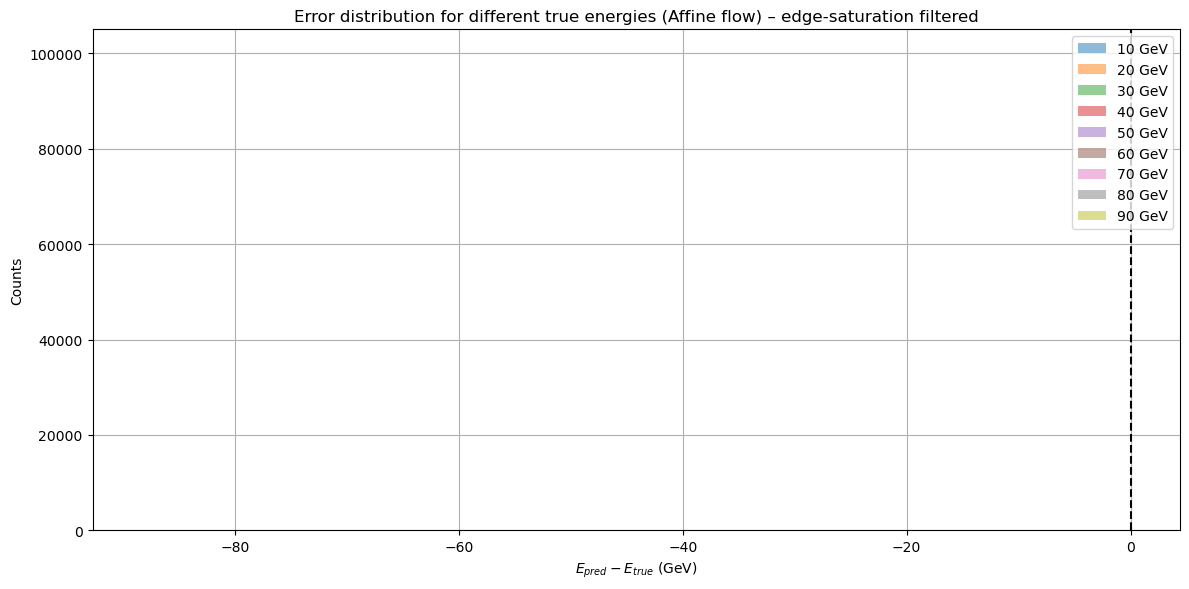

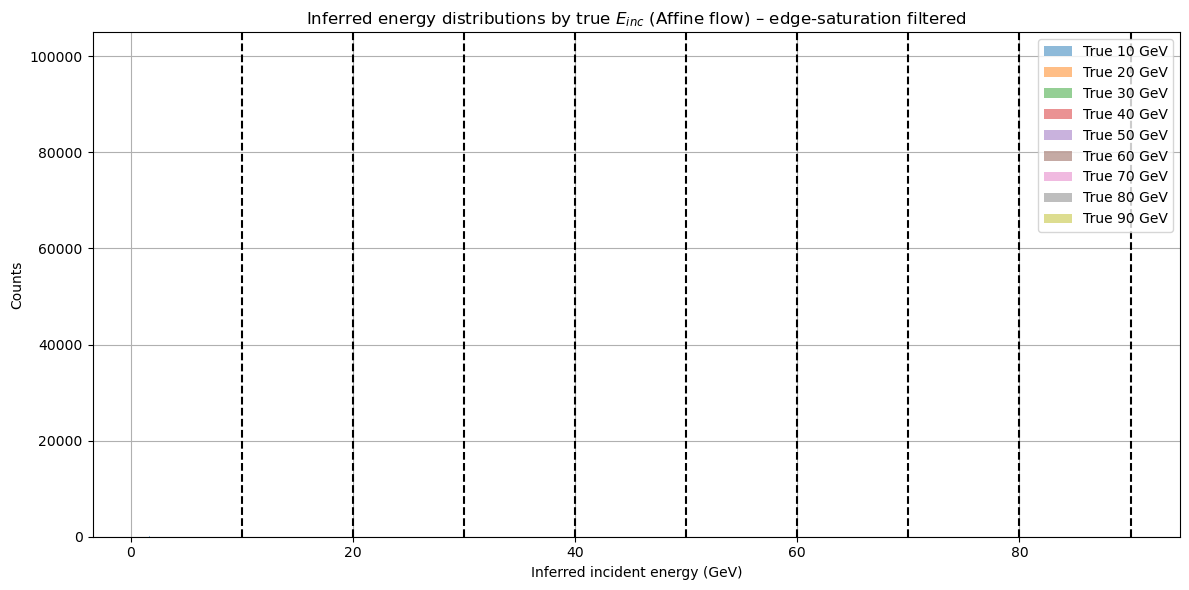


=== Per-energy regression summary (edge-saturation filtered) ===
E_true [GeV]        N   Bias [GeV]  MAE [GeV]  RMSE [GeV]  Std [GeV]  68% width [GeV]  Sat. frac
        10   100000       -8.305      8.305       8.305      0.000            0.000     0.00%
        20   100000      -18.305     18.305      18.305      0.000            0.000     0.00%
        30   100000      -28.305     28.305      28.305      0.000            0.000     0.00%
        40   100000      -38.305     38.305      38.305      0.000            0.000     0.00%
        50   100000      -48.305     48.305      48.305      0.000            0.000     0.00%
        60   100000      -58.305     58.305      58.305      0.000            0.000     0.00%
        70   100000      -68.305     68.305      68.305      0.000            0.000     0.00%
        80   100000      -78.305     78.305      78.305      0.000            0.000     0.00%
        90   100000      -88.305     88.305      88.305      0.000            0.000  

In [6]:
# ============================================================
# ADD-ON SECTION: Multi-energy regression evaluation summary
# (keeps your affine code unchanged; uses its trained flow + stats)
# ============================================================
import os
import time
import numpy as np
import h5py
import torch
import matplotlib.pyplot as plt

eval_folder = '/groups/hephy/mlearning/CaloRegression/evaluation'
energy_values = list(range(10, 91, 10))   # 10,20,...,90

# --- define effective scan max within training support (avoids logit clamp plateau) ---
Emin = 1.0
Emax_eff = float(data_max[0].item()) * 0.999   # assumes data_max[0] is training max energy (GeV)
num_scan_points = 1000
batch_size = 10000

def _logit_reg_torch(x):
    return torch.log(x / (1.0 - x))

def _logit_trafo_reg_torch(x):
    local_x = torch.clamp(ALPHA + (1. - 2. * ALPHA) * x, min=1e-6, max=1 - 1e-6)
    return _logit_reg_torch(local_x)

# --- preprocessing for test files: MUST match training preprocessing for layer features ---
def load_and_preprocess_layers_only(filepath, data_mean, data_std, data_max, device):
    with h5py.File(filepath, 'r') as f:
        energy = f['energy'][:]
        layers = [f[f'layer_{i}'][:] for i in range(6)]
        E_layers = np.array([layer.sum(axis=(1, 2)) for layer in layers]).T

    data = np.hstack((energy.reshape(-1, 1), E_layers))
    data[np.isinf(data)] = np.nan
    data = data[~np.isnan(data).any(axis=1)]

    x = torch.tensor(data, dtype=torch.float32, device=device)
    x = x / data_max                       # normalize by max (vector)
    x = _logit_trafo_reg_torch(x)          # logit trafo (vector)
    # IMPORTANT: your affine snippet had standardization commented out.
    # For correct likelihood usage, we must mirror whatever the FLOW was trained with.
    # Your affine training earlier DID standardize (data_tensor = (data_tensor - mean)/std).
    # Therefore we standardize here:
    x = (x - data_mean) / data_std

    return x[:, 1:]   # layers only

# --- correct likelihood-scan inference for E_inc ---
def infer_incident_energy_scan(flow, layer_tensor, data_mean, data_std, data_max,
                               Emin, Emax_eff, num_scan_points=1000, batch_size=10000):
    device = layer_tensor.device
    n = layer_tensor.shape[0]

    # candidate energies in GeV, restricted to training support
    E_candidates = torch.linspace(Emin, Emax_eff, num_scan_points, device=device).view(-1, 1)

    # preprocess E_inc exactly like training column 0
    E_norm  = E_candidates / data_max[0]                 # scalar
    E_logit = _logit_trafo_reg_torch(E_norm)
    E_std   = (E_logit - data_mean[0]) / data_std[0]

    # broadcast context + inputs
    inputs  = layer_tensor.unsqueeze(1).repeat(1, num_scan_points, 1)   # [n, S, 6]
    context = E_std.view(1, -1, 1).repeat(n, 1, 1)                      # [n, S, 1]

    flat_inputs  = inputs.view(-1, inputs.shape[-1])
    flat_context = context.view(-1, 1)

    logps = []
    flow.eval()
    with torch.no_grad():
        for i in range(0, flat_inputs.shape[0], batch_size):
            logps.append(flow.log_prob(flat_inputs[i:i+batch_size],
                                       context=flat_context[i:i+batch_size]))

    logps = torch.cat(logps).view(n, num_scan_points)
    argmax = logps.argmax(dim=1)

    inferred = E_candidates[argmax].squeeze(1).cpu().numpy()
    saturated = ((argmax == 0) | (argmax == num_scan_points - 1)).cpu().numpy()

    return inferred, saturated

# ============================================================
# Run evaluation over multiple energies + summaries
# ============================================================
errors_by_energy = {}
inferred_by_energy = {}
sat_frac_by_energy = {}

reg_start_time = time.time()

for E_true in energy_values:
    file_path = os.path.join(eval_folder, f'piplus_{E_true}GeV.hdf5')

    layers = load_and_preprocess_layers_only(file_path, data_mean, data_std, data_max, device)
    inferred, saturated = infer_incident_energy_scan(
        flow, layers, data_mean, data_std, data_max,
        Emin=Emin, Emax_eff=Emax_eff, num_scan_points=num_scan_points, batch_size=batch_size
    )

    sat_frac = float(np.mean(saturated))
    sat_frac_by_energy[E_true] = sat_frac

    inferred_clean = inferred[~saturated]
    if len(inferred_clean) == 0:
        inferred_clean = inferred  # fallback if everything saturated

    err = inferred_clean - E_true

    errors_by_energy[E_true] = err
    inferred_by_energy[E_true] = inferred_clean

    print(f"{E_true:3d} GeV | Bias={err.mean():+.2f} | Std={err.std():.2f} | Sat.frac={sat_frac:.2%}")

reg_end_time = time.time()
elapsed = reg_end_time - reg_start_time
h, rem = divmod(elapsed, 3600)
m, s = divmod(rem, 60)
print(f"\nTotal regression time (multi-energy): {int(h)}h {int(m)}m {s:.2f}s")

# ============================================================
# Plots (same idea as your MAF output)
# ============================================================
plt.figure(figsize=(12, 6))
for E_true, err in errors_by_energy.items():
    plt.hist(err, bins=50, alpha=0.5, label=f"{E_true} GeV")
plt.axvline(0, color='black', linestyle='--')
plt.xlabel(r"$E_{pred} - E_{true}$ (GeV)")
plt.ylabel("Counts")
plt.title("Error distribution for different true energies (Affine flow) – edge-saturation filtered")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for E_true, inferred_clean in inferred_by_energy.items():
    plt.hist(inferred_clean, bins=100, range=(Emin, Emax_eff), alpha=0.5, label=f"True {E_true} GeV")
    plt.axvline(E_true, color='black', linestyle='--')
plt.xlabel("Inferred incident energy (GeV)")
plt.ylabel("Counts")
plt.title("Inferred energy distributions by true $E_{inc}$ (Affine flow) – edge-saturation filtered")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# Final numerical summary: per-energy + global (like your MAF summary)
# ============================================================
print("\n=== Per-energy regression summary (edge-saturation filtered) ===")
print("{:>10} {:>8} {:>12} {:>10} {:>11} {:>10} {:>16} {:>10}".format(
    "E_true [GeV]", "N", "Bias [GeV]", "MAE [GeV]", "RMSE [GeV]", "Std [GeV]", "68% width [GeV]", "Sat. frac"
))

all_err = []
all_rel_err = []
total_n = 0

for E_true in energy_values:
    err = np.asarray(errors_by_energy[E_true]).reshape(-1)
    n = len(err)
    total_n += n

    bias = float(np.mean(err))
    mae  = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    std  = float(np.std(err))
    q16, q84 = np.quantile(err, [0.16, 0.84])
    width68 = float(q84 - q16)

    sat = float(sat_frac_by_energy[E_true])

    all_err.append(err)
    all_rel_err.append(err / E_true)

    print("{:>10.0f} {:>8d} {:>12.3f} {:>10.3f} {:>11.3f} {:>10.3f} {:>16.3f} {:>9.2%}".format(
        E_true, n, bias, mae, rmse, std, width68, sat
    ))

all_err = np.concatenate(all_err) if len(all_err) else np.array([])
all_rel_err = np.concatenate(all_rel_err) if len(all_rel_err) else np.array([])

print("\n=== Global regression summary (all energies pooled) ===")
print(f"Total N: {total_n}")

if len(all_err) > 0:
    global_bias = float(np.mean(all_err))
    global_mae  = float(np.mean(np.abs(all_err)))
    global_rmse = float(np.sqrt(np.mean(all_err**2)))
    global_std  = float(np.std(all_err))
    gq16, gq84 = np.quantile(all_err, [0.16, 0.84])
    global_width68 = float(gq84 - gq16)

    global_rel_mae = float(np.mean(np.abs(all_rel_err)))
    global_rel_rmse = float(np.sqrt(np.mean(all_rel_err**2)))

    print(f"Bias  [GeV]: {global_bias:.3f}")
    print(f"MAE   [GeV]: {global_mae:.3f}")
    print(f"RMSE  [GeV]: {global_rmse:.3f}")
    print(f"Std   [GeV]: {global_std:.3f}")
    print(f"68% width [GeV]: {global_width68:.3f}")
    print(f"Relative MAE  [%]: {100*global_rel_mae:.3f}")
    print(f"Relative RMSE [%]: {100*global_rel_rmse:.3f}")
else:
    print("No errors collected.")
